<font size="4"> Introduction: 

<font size="4"> This project investigates how urban, rural, or suburban counties affect the vote share of Democratic and Republican candidates in U.S. elections. We used the number of county votes as a way to create these divides, assuming that a smaller voting population means a more rural area and vice versa. We are specifically interested in whether larger (more urban) counties vote more Democratic, and smaller (more rural) counties more Republican. Additionally, we explore whether this relationship reflects across different election types, such as Presidential, Senate, and Governor elections.

<font size="4"> It is important to explore this relationship in order to understand urban and rural political differences. By studying these patterns, we can better understand whether voting behavior is associated with population distribution and whether this trend holds constant between Presidential, Senate, and Governor elections.

<font size="4"> Data Description: 

<font size="4"> This analysis uses six datasets from the 2020 U.S. election, including the county-level and candidate-level results for presidential, senate, and governor elections. We are using the "president_county.csv" and the "president_county_candidate.csv" to investigate voting behavior for the presidential election. We are using the "senate_county_candidate.csv" and "senate_county.csv" to investigate voting behavior for the Senate. Finally, we are using "governors_county_candidate.csv" and "governors_county.csv" for governor voting behavior.

<font size="4"> Each dataset contains rows representing vote counts for a candidate within a specific county and state. The county-level files include total votes cast in each county, while the candidate-level files include the number of votes received by each candidate. After merging, each row represents a party's performance in a specific county.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd

In [12]:
president_county = pd.read_csv("4-US_Election_2020/president_county.csv")
president_cand = pd.read_csv("4-US_Election_2020/president_county_candidate.csv")

senator_county = pd.read_csv("4-US_Election_2020/senate_county.csv")
senator_cand = pd.read_csv("4-US_Election_2020/senate_county_candidate.csv")

governor_county = pd.read_csv("4-US_Election_2020/governors_county.csv")
governor_cand = pd.read_csv("4-US_Election_2020/governors_county_candidate.csv")

In [13]:
len(president_county), len(president_cand)
len(senator_county), len(senator_cand)
len(governor_county), len(governor_cand)

(1025, 5145)

<font size="3"> To combine candidate-level and county-level information, the datasets were merged on the shared columns of state and county. A left join was used to ensure that all candidate-level observations were kept in the dataset while adding total county vote information. By merging, we created a singular dataset where each row contains both candidate votes and total county votes, enabling the calculation of vote share.

In [3]:
president_merged = pd.merge(president_cand, president_county, on = ["state", "county"], how = "left")
senator_merged = pd.merge(senator_cand, senator_county, on = ["state", "county"], how = "left")
governor_merged = pd.merge(governor_cand, governor_county, on = ["state", "county"], how = "left")

<font size="3"> Data Cleaning: 

<font size="3"> The data was cleaned to standardize formatting and ensure consistency across datasets. First, whitespace was removed from string columns such as state, county, and party. Party labels were standardized so that abbreviations like “DEM” and “REP” were replaced with full names, "Democrat" and "Republican." The dataset was then filtered to include only Democratic and Republican candidates, excluding third-party candidates for clearer comparison.

<font size="3"> Column names were also standardized across datasets to ensure consistency. For example, candidate vote counts were all renamed to "Candidate Votes" and total county votes were renamed to "County Total" to keep the dataset consistent and comparable, regardless of their original column titles. 

In [4]:
def clean_election(df):
    df["state"] = df["state"].str.strip()
    df["county"] = df["county"].str.strip()
    df["party"] = df["party"].str.strip()

    df["party"] = df["party"].replace({"DEM": "DEMOCRAT", "REP": "REPUBLICAN"})
    df = df.query("party == 'DEMOCRAT' or party == 'REPUBLICAN'")

    if "total_votes_x" in df.columns:
        df = df.rename(columns = {"total_votes_x": "candidate_votes"})
    elif "votes" in df.columns:
        df = df.rename(columns = {"votes": "candidate_votes"})
    elif "total_votes" in df.columns:
        df = df.rename(columns = {"total_votes": "candidate_votes"})

    if "current_votes" in df.columns:
        df = df.rename(columns = {"current_votes": "county_total"})
    elif "total_votes_y" in df.columns:
        df = df.rename(columns = {"total_votes_y": "county_total"})

    return df[["state", "county", "party", "candidate_votes", "county_total"]]

In [5]:
president_clean = clean_election(president_merged)
senator_clean = clean_election(senator_merged)
governor_clean = clean_election(governor_merged)

# print(f"Number of rows found: {len(president_clean)}")
# display(president_clean.head())
# print(f"Number of rows found: {len(senator_clean)}")
# display(senator_clean.head())
# print(f"Number of rows found: {len(governor_clean)}")
# display(governor_clean.head())


In [6]:
def vote_share(df):
    df['vote_share'] = (df['candidate_votes'] / df['county_total']) * 100

    county_bins = [-1, 50000, 1000000, np.inf]
    county_labels = ["rural", "suburban", "urban"]

    df['county_size'] = pd.cut(df['county_total'],
                               bins = county_bins,
                               labels = county_labels)

    graph = df.groupby(['county_size', 'party'], observed=  False).agg(
        avg_vote_share = ('vote_share', 'mean')).reset_index()

    return graph

president_graph = vote_share(president_clean)
senator_graph = vote_share(senator_clean)
governor_graph = vote_share(governor_clean)

In [7]:
def plot_bar(df, title): 
    plt.figure(figsize=(10,6))

    sizes = ["rural", "suburban", "urban"]
    
    dem_vals = []
    rep_vals = []
    
    for size in sizes:
        dem = df[(df["county_size"] == size) & (df["party"] == "DEMOCRAT")]
        rep = df[(df["county_size"] == size) & (df["party"] == "REPUBLICAN")]
        dem_vals.append(dem["avg_vote_share"].values[0])
        rep_vals.append(rep["avg_vote_share"].values[0])
    
    x = [0, 1, 2]
    
    plt.bar(x, dem_vals, width = 0.4, label = "DEMOCRAT", color = "blue") 
    plt.bar([0.4, 1.4, 2.4], rep_vals, width = 0.4, label = "REPUBLICAN" , color = "red")

    plt.xticks([0.2, 1.2, 2.2], sizes)
    
    plt.xlabel ("County Size")
    plt.ylabel("'Average Vote Share (%)")
    plt.title(title)
    plt.legend()
    plt.show()

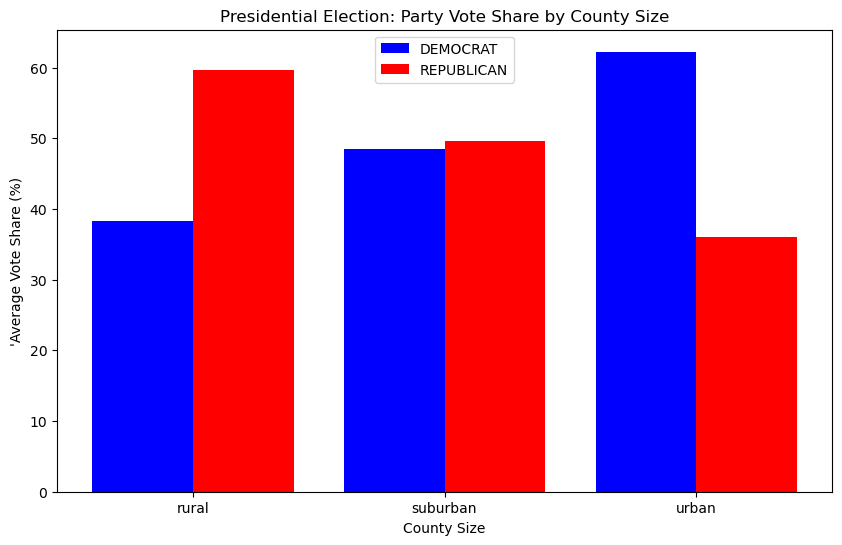

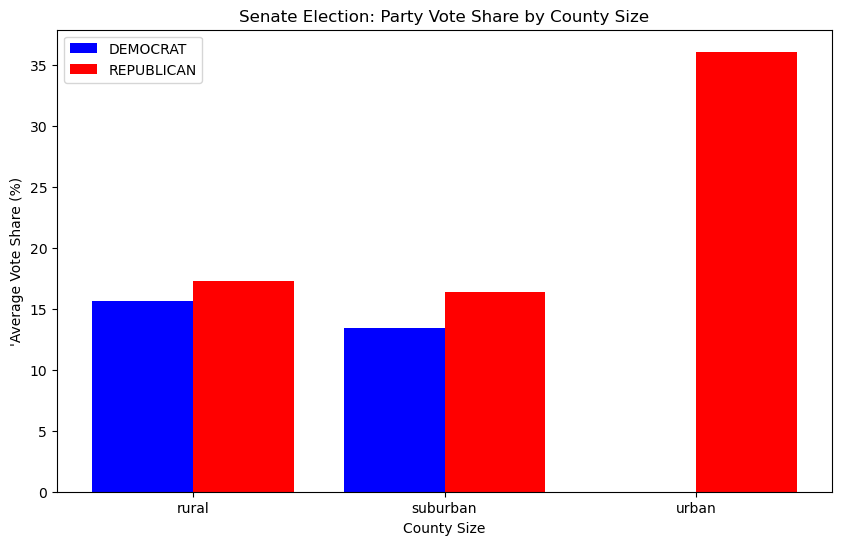

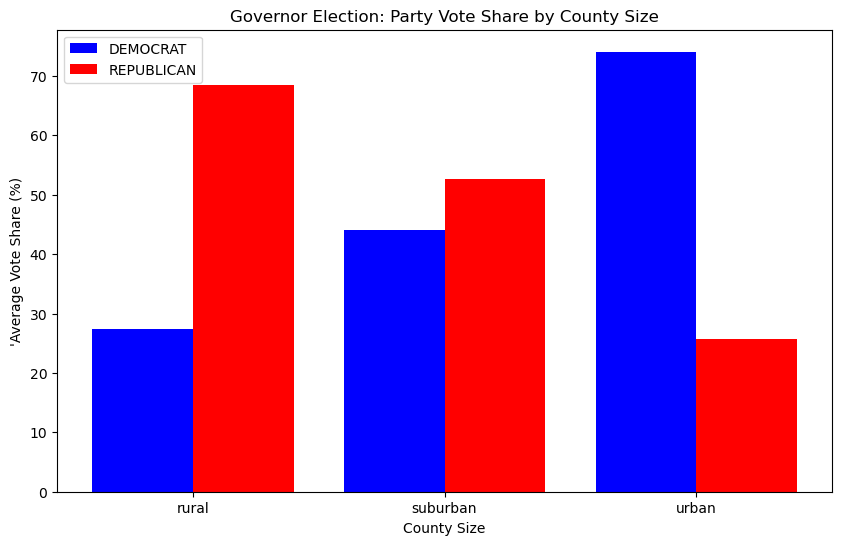

In [8]:
plot_bar(president_graph, "Presidential Election: Party Vote Share by County Size")
plot_bar(senator_graph, "Senate Election: Party Vote Share by County Size")
plot_bar(governor_graph, "Governor Election: Party Vote Share by County Size")

In [9]:
president_graph["office"] = "President"
senator_graph["office"] = "Senate"
governor_graph["office"] = "Governor"

combined_graph = pd.concat([president_graph, senator_graph, governor_graph])

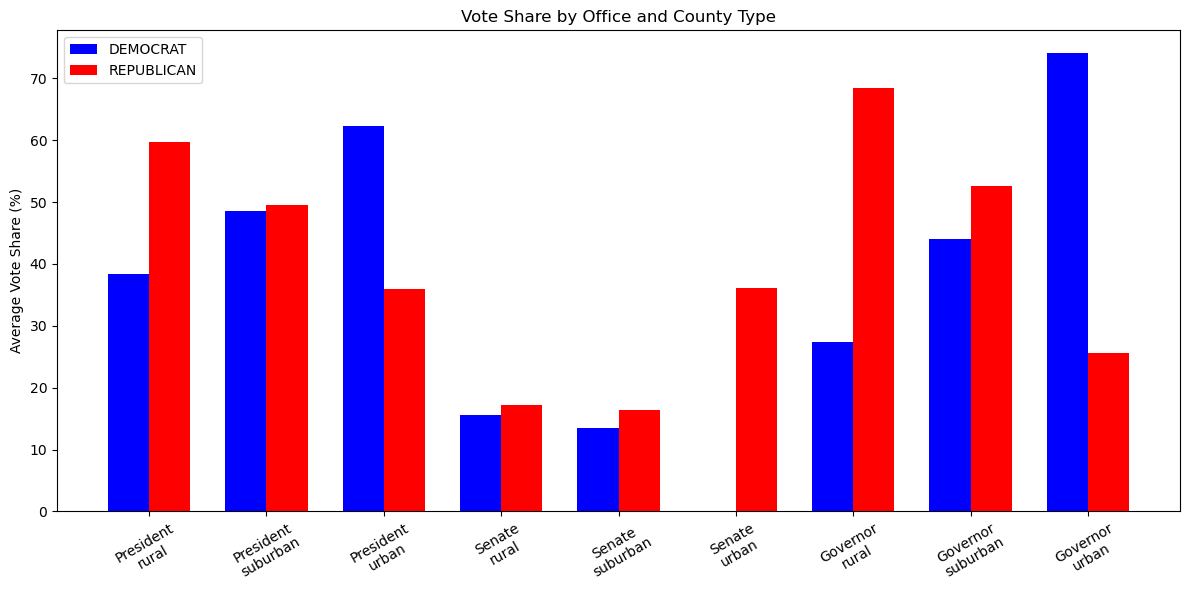

In [10]:
def plot_all_groups(df):
    plt.figure(figsize = (12,6))

    offices = ["President", "Senate", "Governor"]
    sizes = ["rural", "suburban", "urban"]

    x_labels = []
    dem_vals = []
    rep_vals = []

    # build 9 groups
    for office in offices:
        for size in sizes:
            subset = df[(df["office"] == office) & (df["county_size"] == size)]

            dem = subset[subset["party"] == "DEMOCRAT"]["avg_vote_share"]
            rep = subset[subset["party"] == "REPUBLICAN"]["avg_vote_share"]

            dem_vals.append(dem.values[0])
            rep_vals.append(rep.values[0])

            x_labels.append(f"{office}\n{size}")

    x = np.arange(len(x_labels))
    width = 0.35

    plt.bar(x - width/2, dem_vals, width, label="DEMOCRAT", color="blue")
    plt.bar(x + width/2, rep_vals, width, label="REPUBLICAN", color="red")

    plt.xticks(x, x_labels, rotation=30)
    plt.ylabel("Average Vote Share (%)")
    plt.title("Vote Share by Office and County Type")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_all_groups(combined_graph)


In [11]:
senator_merged.query("county == 'Cook County' and state == 'Illinois'").drop(columns = ['percent', 'candidate'])

,state,county,party,total_votes_x,current_votes,total_votes_y
904,Illinois,Cook County,REPUBLICAN,499034,2289749,2417649
905,Illinois,Cook County,OTH,168295,2289749,2417649
906,Illinois,Cook County,GRN,25041,2289749,2417649
907,Illinois,Cook County,LIB,22694,2289749,2417649
908,Illinois,Cook County,WRI,0,2289749,2417649
